In [125]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, classification_report,confusion_matrix,
    roc_curve, auc, roc_auc_score
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

In [2]:
users        = pd.read_csv("users.csv")
interactions = pd.read_csv("interactions.csv")
full         = pd.read_csv("home_appliance_recommendation_full.csv")

print(f"  users.csv          → {users.shape[0]} rows, {users.shape[1]} columns")
print(f"  interactions.csv   → {interactions.shape[0]} rows, {interactions.shape[1]} columns")
print(f"  full_dataset.csv   → {full.shape[0]} rows, {full.shape[1]} columns")

  users.csv          → 2000 rows, 10 columns
  interactions.csv   → 15000 rows, 10 columns
  full_dataset.csv   → 15000 rows, 59 columns


In [3]:
users = users.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Drop duplicate users (keep first)
before = len(users)
users = users.drop_duplicates(subset="User_ID")
print(f"  Duplicate users removed : {before - len(users)}")

# Check nulls — users.csv has none, but handle defensively
users = users.fillna("Unknown")

print(f"  Final users shape       : {users.shape}")
print(f"  Columns                 : {list(users.columns)}")


  Duplicate users removed : 0
  Final users shape       : (2000, 10)
  Columns                 : ['User_ID', 'Age_Group', 'Gender', 'Occupation', 'City', 'Home_Type', 'Budget_Preference', 'Smart_Home_Interest', 'Eco_Conscious', 'Preferred_Category']


In [4]:
interactions = interactions.apply(
    lambda col: col.str.strip() if col.dtype == "object" else col
)
interactions["User_Rating_Given"]   = interactions["User_Rating_Given"].fillna(0)
interactions["Session_Duration_sec"] = interactions["Session_Duration_sec"].fillna(
    interactions["Session_Duration_sec"].median()
)

print(f"  Nulls after fix:")
print(f"    User_Rating_Given    : {interactions['User_Rating_Given'].isnull().sum()}")
print(f"    Session_Duration_sec : {interactions['Session_Duration_sec'].isnull().sum()}")

# Convert Interaction_Date to datetime
interactions["Interaction_Date"] = pd.to_datetime(
    interactions["Interaction_Date"], errors="coerce"
)
event_weight = {
    "purchase":    4,
    "add_to_cart": 3,
    "wishlist":    2,
    "view":        1
}
interactions["Event_Score"] = interactions["Event_Type"].map(event_weight).fillna(1)

print(f"  Event_Score created     : Done")
print(f"  Final interactions shape: {interactions.shape}")


  Nulls after fix:
    User_Rating_Given    : 0
    Session_Duration_sec : 0
  Event_Score created     : Done
  Final interactions shape: (15000, 11)


In [5]:
full = full.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# Fix nulls
#   Display_Type and Connectivity — fill with "Not Applicable"
full["Display_Type"] = full["Display_Type"].fillna("Not Applicable")
full["Connectivity"] = full["Connectivity"].fillna("Not Applicable")
full["User_Rating_Given"] = full["User_Rating_Given"].fillna(0)
full["Session_Duration_sec"] = full["Session_Duration_sec"].fillna(
    full["Session_Duration_sec"].median()
)

print(f"  Nulls after fix:")
print(f"    Display_Type         : {full['Display_Type'].isnull().sum()}")
print(f"    Connectivity         : {full['Connectivity'].isnull().sum()}")


  Nulls after fix:
    Display_Type         : 0
    Connectivity         : 0


In [6]:
# Map Energy_Rating to numeric score for ranking
energy_map = {
    "A+++": 7, "A++": 6, "A+": 5,
    "A": 4, "B": 3, "C": 2, "D": 1
}
full["Energy_Score"] = full["Energy_Rating"].map(energy_map).fillna(3)

In [7]:
# Map Budget_Segment to numeric
budget_map = {
    "Budget":    1,
    "Mid-Range": 2,
    "Premium":   3,
    "Luxury":    4
}
full["Budget_Score"] = full["Budget_Segment"].map(budget_map).fillna(2)

In [8]:
# Map Budget_Preference (from user profile) to numeric
full["Budget_Pref_Score"] = full["Budget_Preference"].map(budget_map).fillna(2)

In [9]:
# Binary flags: Yes/No → 1/0
yes_no_cols = [
    "Smart_Feature", "WiFi_Connectivity", "Voice_Control", "App_Control",
    "Installation_Required", "Portable", "Child_Lock", "Auto_Shutoff",
    "Timer_Function", "Inverter_Technology", "Remote_Control",
    "Touch_Control", "Eco_Friendly", "Made_in_India",
    "Smart_Home_Interest", "Eco_Conscious"
]
for col in yes_no_cols:
    if col in full.columns:
        full[col] = full[col].map({"Yes": 1, "No": 0}).fillna(0).astype(int)
print(f"  Energy_Score created    : Done")
print(f"  Budget_Score created    : Done")
print(f"  Binary flags encoded   : {len(yes_no_cols)} columns")
print(f"  Final full shape        : {full.shape}")


  Energy_Score created    : Done
  Budget_Score created    : Done
  Binary flags encoded   : 16 columns
  Final full shape        : (15000, 62)


In [10]:
interactions_slim = interactions[
    ["Interaction_ID", "User_ID", "Appliance_ID", "Event_Score"]
].copy()

merged = full.merge(interactions_slim, on=["Interaction_ID", "User_ID", "Appliance_ID"], how="left")
merged["Event_Score"] = merged["Event_Score"].fillna(1)

In [11]:
users_slim = users[["User_ID", "Occupation", "Home_Type"]].copy()
users_slim.columns = ["User_ID", "Occupation_clean", "Home_Type_clean"]

merged = merged.merge(users_slim, on="User_ID", how="left")

print(f"  Merged dataset shape    : {merged.shape}")
print(f"  Total null values       : {merged.isnull().sum().sum()}")

  Merged dataset shape    : (15000, 65)
  Total null values       : 0


In [12]:
merged["Recommendation_Score"] = (
    merged["User_Rating"]        * 0.30 +  # Product quality
    merged["Energy_Score"]       * 0.20 +  # Energy efficiency
    merged["Event_Score"]        * 0.20 +  # User engagement
    merged["Warranty_Years"]     * 0.15 +  # Reliability
    merged["User_Rating_Given"]  * 0.15    # Personal rating
)


In [13]:
# Budget match flag: 1 if user budget matches product budget segment
merged["Budget_Match"] = (
    merged["Budget_Score"] == merged["Budget_Pref_Score"]
).astype(int)

# Category match flag: 1 if product category matches user preferred category
merged["Category_Match"] = (
    merged["Category"] == merged["Preferred_Category"]
).astype(int)

print(f"  Recommendation_Score created : Done")
print(f"  Budget_Match created         : Done")
print(f"  Category_Match created       : Done")

  Recommendation_Score created : Done
  Budget_Match created         : Done
  Category_Match created       : Done


In [14]:
#LABEL ENCODE CATEGORICAL COLUMNS
categorical_cols = [
    "Gender", "Age_Group", "Category", "Preferred_Category",
    "Budget_Preference", "Budget_Segment", "Home_Appliance",
    "Company", "Noise_Level_Category", "Suitable_Room",
    "Maintenance_Level", "After_Sales_Service", "Availability",
    "Size_Category", "Power_Source", "Color", "Material",
    "Energy_Rating", "Event_Type", "City", "Home_Type"
]
le = LabelEncoder()
label_map = {}  # Save mappings for future decoding

for col in categorical_cols:
    if col in merged.columns:
        merged[col + "_Encoded"] = le.fit_transform(merged[col].astype(str))
        label_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print(f"  Columns encoded: {len([c for c in categorical_cols if c in merged.columns])}")

  Columns encoded: 21


In [15]:
# SCALE NUMERIC COLUMNS
numeric_cols = [
    "Price_INR", "User_Rating", "Number_of_Reviews",
    "Annual_Energy_Consumption_kWh", "Power_Consumption_Watts",
    "Noise_Level_dB", "Weight_kg", "Lifespan_Years",
    "Session_Duration_sec", "Recommendation_Score"
]

scaler = MinMaxScaler()
for col in numeric_cols:
    if col in merged.columns:
        merged[col + "_Scaled"] = scaler.fit_transform(merged[[col]])

print(f"  Columns scaled: {len([c for c in numeric_cols if c in merged.columns])}")

  Columns scaled: 10


In [16]:
# SELECT FINAL FEATURES FOR MODEL
final_features = [
    # Identifiers
    "User_ID", "Appliance_ID", "Home_Appliance", "Company", "Category",

    # User profile
    "Gender", "Age_Group", "Budget_Preference", "Preferred_Category",
    "Smart_Home_Interest", "Eco_Conscious",

    # Product features
    "Price_INR", "Budget_Segment", "Energy_Rating", "User_Rating",
    "Warranty_Years", "Smart_Feature", "WiFi_Connectivity",
    "Eco_Friendly", "Made_in_India", "Inverter_Technology",

    # Engineered features
    "Energy_Score", "Budget_Score", "Budget_Match",
    "Category_Match", "Event_Score", "Recommendation_Score",

    # Encoded columns
    "Gender_Encoded", "Age_Group_Encoded", "Category_Encoded",
    "Budget_Segment_Encoded", "Company_Encoded", "Home_Appliance_Encoded",
    "Energy_Rating_Encoded", "Event_Type_Encoded",

    # Scaled columns
    "Price_INR_Scaled", "User_Rating_Scaled",
    "Recommendation_Score_Scaled",

    # Target variable
    "Purchased"
]

# Keep only columns that exist
final_features = [f for f in final_features if f in merged.columns]
final_df = merged[final_features].copy()

print(f"  Final features selected : {len(final_features)}")
print(f"  Final dataset shape     : {final_df.shape}")
print(f"  Target (Purchased) dist :")
print(f"    {final_df['Purchased'].value_counts().to_dict()}")

  Final features selected : 39
  Final dataset shape     : (15000, 39)
  Target (Purchased) dist :
    {0: 10988, 1: 4012}


In [17]:
# STEP 10: SAVE PREPROCESSED DATASET
# ─────────────────────────────────────────────
print("\n" + "=" * 55)
print("STEP 10: Saving preprocessed dataset...")
print("=" * 55)

final_df.to_csv("preprocessed_data.csv", index=False)
print(f"  Saved → preprocessed_data.csv")
print(f"  Shape : {final_df.shape}")

print("\n" + "=" * 55)
print("  PREPROCESSING COMPLETE!")
print("=" * 55)
print(f"\n  Summary:")
print(f"    Total records         : {len(final_df)}")
print(f"    Total features        : {len(final_df.columns)}")
print(f"    Purchased (1)         : {(final_df['Purchased']==1).sum()}")
print(f"    Not purchased (0)     : {(final_df['Purchased']==0).sum()}")
print(f"\n  Next step → Run model_training.py")
print("=" * 55)


STEP 10: Saving preprocessed dataset...
  Saved → preprocessed_data.csv
  Shape : (15000, 39)

  PREPROCESSING COMPLETE!

  Summary:
    Total records         : 15000
    Total features        : 39
    Purchased (1)         : 4012
    Not purchased (0)     : 10988

  Next step → Run model_training.py


In [18]:
# ── Style setup 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#FAFAFA",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})
BLUE   = "#185FA5"
TEAL   = "#1D9E75"
AMBER  = "#BA7517"
PURPLE = "#534AB7"
CORAL  = "#D85A30"
GRAY   = "#888780"
COLORS = [BLUE, TEAL, AMBER, PURPLE, CORAL, GRAY,
          "#639922", "#D4537E", "#0F6E56", "#3C3489"]


Generating Chart 1: Products per category...


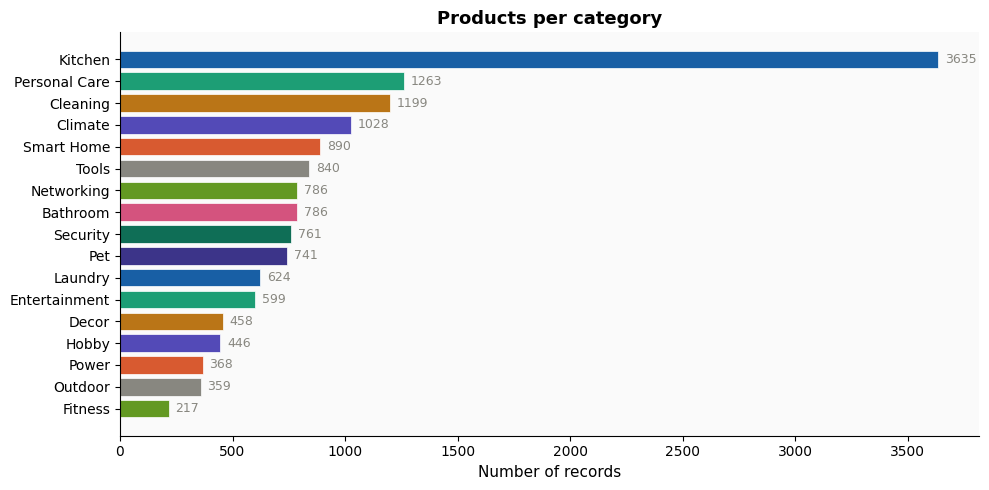

In [19]:
# ── CHART 1: Product count per category ──────────────────
print("\nGenerating Chart 1: Products per category...")
fig, ax = plt.subplots(figsize=(10, 5))
cat_counts = full['Category'].value_counts()
bars = ax.barh(cat_counts.index, cat_counts.values,
               color=COLORS[:len(cat_counts)], edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9, color=GRAY)
ax.set_xlabel("Number of records")
ax.set_title("Products per category")
ax.invert_yaxis()
plt.tight_layout()
# plt.savefig("chart1_category_counts.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 2: Budget segment distribution...


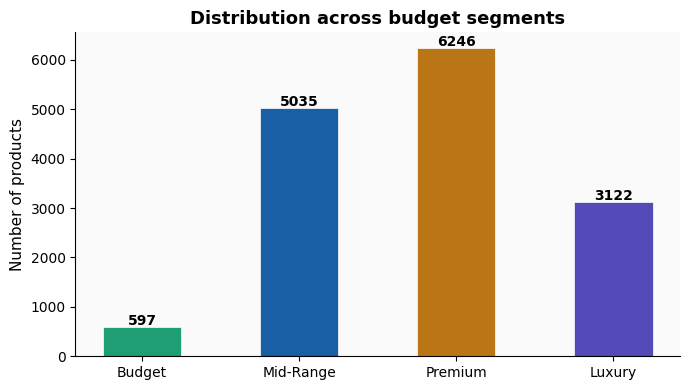

In [20]:
# ── CHART 2: Budget segment distribution ─────────────────
print("Generating Chart 2: Budget segment distribution...")
fig, ax = plt.subplots(figsize=(7, 4))
budget_order = ["Budget", "Mid-Range", "Premium", "Luxury"]
budget_counts = full['Budget_Segment'].value_counts().reindex(budget_order)
budget_colors = [TEAL, BLUE, AMBER, PURPLE]
bars = ax.bar(budget_counts.index, budget_counts.values,
              color=budget_colors, edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, budget_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            str(val), ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Number of products")
ax.set_title("Distribution across budget segments")
plt.tight_layout()
plt.savefig("chart2_budget_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 3: Gender distribution...


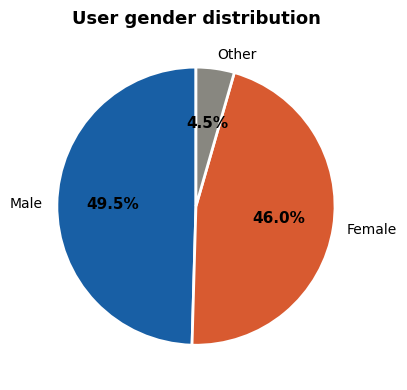

In [21]:
# ── CHART 3: Gender distribution (users) ─────────────────
print("Generating Chart 3: Gender distribution...")
fig, ax = plt.subplots(figsize=(6, 4))
gender_counts = users['Gender'].value_counts()
wedge_colors = [BLUE, CORAL, GRAY]
wedges, texts, autotexts = ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=wedge_colors[:len(gender_counts)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
ax.set_title("User gender distribution")
plt.tight_layout()
plt.savefig("chart3_gender_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 4: Age group vs purchase rate...


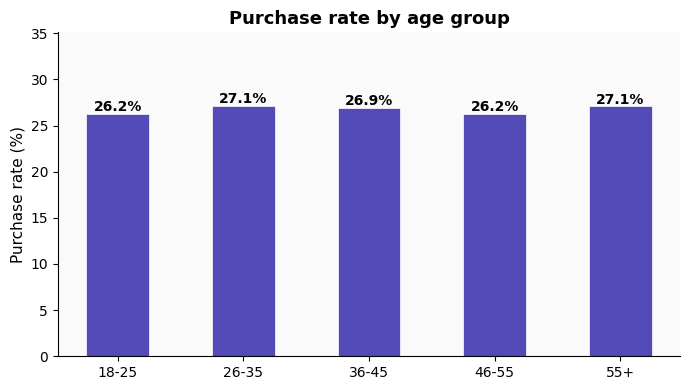

In [22]:
print("Generating Chart 4: Age group vs purchase rate...")
fig, ax = plt.subplots(figsize=(7, 4))
age_order = ["18-25", "26-35", "36-45", "46-55", "55+"]
age_purchase = full.groupby("Age_Group")["Purchased"].mean() * 100
age_purchase = age_purchase.reindex(age_order)
bars = ax.bar(age_purchase.index, age_purchase.values,
              color=PURPLE, edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, age_purchase.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Purchase rate (%)")
ax.set_title("Purchase rate by age group")
ax.set_ylim(0, age_purchase.max() + 8)
plt.tight_layout()
plt.savefig("chart4_age_purchase_rate.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 5: Price distribution by budget...


C:\Users\Alok Raj\AppData\Local\Temp\ipykernel_29052\1015293735.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_budget, labels=budget_order, patch_artist=True,


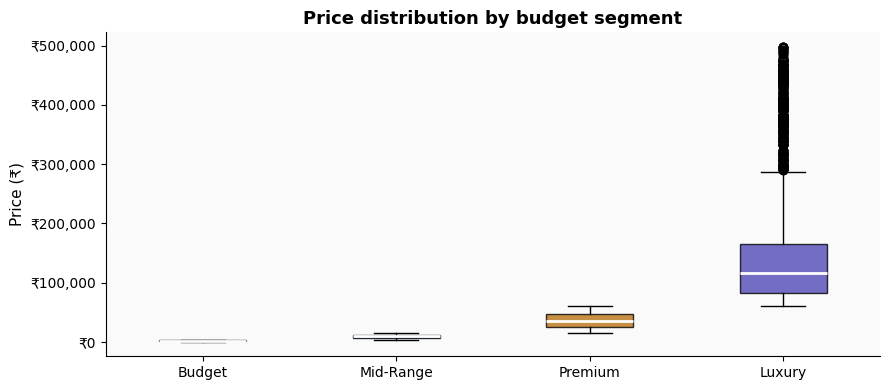

In [23]:
# ── CHART 5: Price distribution per budget segment ───────
print("Generating Chart 5: Price distribution by budget...")
fig, ax = plt.subplots(figsize=(9, 4))
budget_order = ["Budget", "Mid-Range", "Premium", "Luxury"]
data_by_budget = [
    full[full["Budget_Segment"] == seg]["Price_INR"].dropna()
    for seg in budget_order
]
bp = ax.boxplot(data_by_budget, labels=budget_order, patch_artist=True,
                medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(bp["boxes"], [TEAL, BLUE, AMBER, PURPLE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel("Price (₹)")
ax.set_title("Price distribution by budget segment")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"₹{int(x):,}")
)
plt.tight_layout()
plt.savefig("chart5_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 6: Event type breakdown...


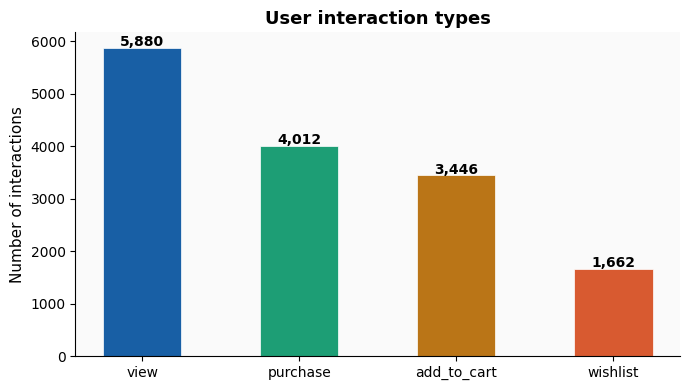

In [24]:
# ── CHART 6: Event type breakdown ────────────────────────
print("Generating Chart 6: Event type breakdown...")
fig, ax = plt.subplots(figsize=(7, 4))
event_counts = interactions['Event_Type'].value_counts()
event_colors = [BLUE, TEAL, AMBER, CORAL]
bars = ax.bar(event_counts.index, event_counts.values,
              color=event_colors[:len(event_counts)],
              edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, event_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Number of interactions")
ax.set_title("User interaction types")
plt.tight_layout()
plt.savefig("chart6_event_types.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 7: Energy rating vs user rating...


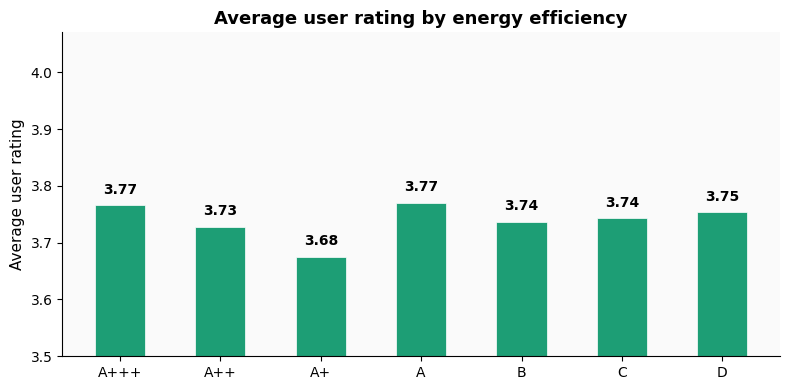

In [25]:
# ── CHART 7: Energy rating vs user rating ────────────────
print("Generating Chart 7: Energy rating vs user rating...")
fig, ax = plt.subplots(figsize=(8, 4))
energy_order = ["A+++", "A++", "A+", "A", "B", "C", "D"]
energy_rating = full.groupby("Energy_Rating")["User_Rating"].mean()
energy_rating = energy_rating.reindex(
    [e for e in energy_order if e in energy_rating.index]
)
bars = ax.bar(energy_rating.index, energy_rating.values,
              color=TEAL, edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, energy_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Average user rating")
ax.set_title("Average user rating by energy efficiency")
ax.set_ylim(3.5, energy_rating.max() + 0.3)
plt.tight_layout()
plt.savefig("chart7_energy_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()

Generating Chart 8: Top 10 purchased brands...


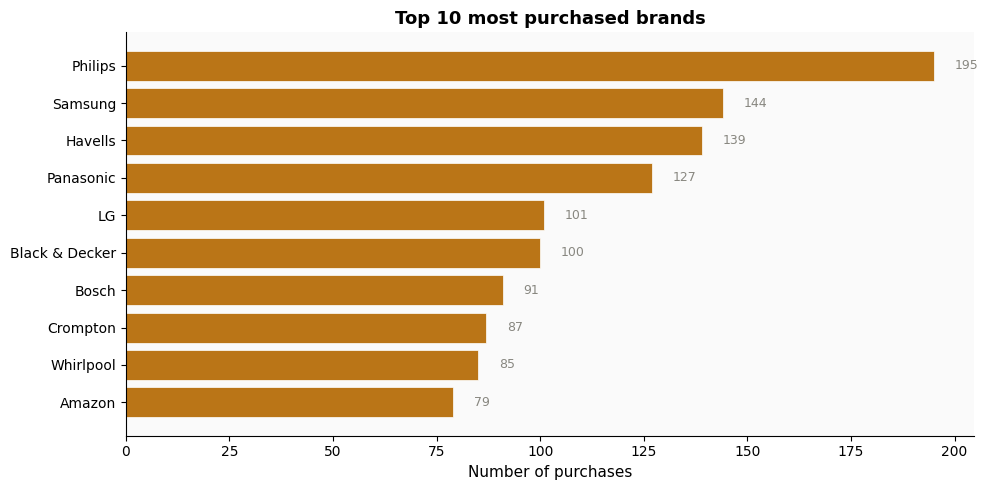

In [26]:
# ── CHART 8: Top 10 most purchased brands ────────────────
print("Generating Chart 8: Top 10 purchased brands...")
fig, ax = plt.subplots(figsize=(10, 5))
top_brands = (
    full[full["Purchased"] == 1]["Company"]
    .value_counts()
    .head(10)
)
bars = ax.barh(top_brands.index, top_brands.values,
               color=AMBER, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, top_brands.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9, color=GRAY)
ax.set_xlabel("Number of purchases")
ax.set_title("Top 10 most purchased brands")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("chart8_top_brands.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
# ── SUMMARY STATS ─────────────────────────────────────────
print("\n" + "=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"  Total records          : {len(full):,}")
print(f"  Total users            : {len(users):,}")
print(f"  Total interactions     : {len(interactions):,}")
print(f"  Total categories       : {full['Category'].nunique()}")
print(f"  Total brands           : {full['Company'].nunique()}")
print(f"  Total appliance types  : {full['Home_Appliance'].nunique()}")
print(f"  Price range            : ₹{full['Price_INR'].min():,.0f} – ₹{full['Price_INR'].max():,.0f}")
print(f"  Avg user rating        : {full['User_Rating'].mean():.2f} / 5")
print(f"  Overall purchase rate  : {full['Purchased'].mean()*100:.1f}%")
print(f"  Smart feature %        : {(full['Smart_Feature']=='Yes').mean()*100:.1f}%")
print(f"  Eco-friendly %         : {(full['Eco_Friendly']=='Yes').mean()*100:.1f}%")
print("\n  Charts saved:")
for i in range(1, 9):
    names = [
        "category counts", "budget distribution", "gender distribution",
        "age vs purchase", "price distribution", "event types",
        "energy vs rating", "top brands"
    ]
    print(f"    chart{i}_{names[i-1].replace(' ','_')}.png")
print("\n  Next step → Run model_training.py")
print("=" * 55)


EDA SUMMARY
  Total records          : 15,000
  Total users            : 2,000
  Total interactions     : 15,000
  Total categories       : 17
  Total brands           : 144
  Total appliance types  : 245
  Price range            : ₹200 – ₹497,900
  Avg user rating        : 3.74 / 5
  Overall purchase rate  : 26.7%
  Smart feature %        : 0.0%
  Eco-friendly %         : 0.0%

  Charts saved:
    chart1_category_counts.png
    chart2_budget_distribution.png
    chart3_gender_distribution.png
    chart4_age_vs_purchase.png
    chart5_price_distribution.png
    chart6_event_types.png
    chart7_energy_vs_rating.png
    chart8_top_brands.png

  Next step → Run model_training.py


In [28]:
print("\nPreparing product feature matrix...")

# Map Energy Rating to numeric score
energy_map = {
    "A+++": 7, "A++": 6, "A+": 5,
    "A":    4, "B":   3, "C": 2, "D": 1
}


Preparing product feature matrix...


In [29]:
# Map Budget Segment to numeric
budget_map = {
    "Budget":    1,
    "Mid-Range": 2,
    "Premium":   3,
    "Luxury":    4
}

# Create clean product dataframe
products = full[[
    "Appliance_ID", "Home_Appliance", "Company",
    "Category", "Budget_Segment", "Price_INR",
    "Energy_Rating", "User_Rating", "Smart_Feature",
    "Eco_Friendly", "Warranty_Years", "Inverter_Technology",
    "Number_of_Reviews", "Lifespan_Years"
]].copy()

# Drop duplicates — keep best rated per appliance+brand
products = products.sort_values("User_Rating", ascending=False)
products = products.drop_duplicates(subset=["Home_Appliance", "Company"])
products = products.reset_index(drop=True)

# Encode features
products["Energy_Score"]  = products["Energy_Rating"].map(energy_map).fillna(3)
products["Budget_Score"]  = products["Budget_Segment"].map(budget_map).fillna(2)
products["Smart_Score"]   = products["Smart_Feature"].map({"Yes": 1, "No": 0}).fillna(0)
products["Eco_Score"]     = products["Eco_Friendly"].map({"Yes": 1, "No": 0}).fillna(0)
products["Inverter_Score"]= products["Inverter_Technology"].map({"Yes": 1, "No": 0}).fillna(0)

# Normalise numeric columns to 0-1
scaler = MinMaxScaler()
products["Rating_Norm"]   = scaler.fit_transform(products[["User_Rating"]])
products["Price_Norm"]    = scaler.fit_transform(products[["Price_INR"]])
products["Warranty_Norm"] = scaler.fit_transform(products[["Warranty_Years"]])
products["Reviews_Norm"]  = scaler.fit_transform(products[["Number_of_Reviews"]])
products["Lifespan_Norm"] = scaler.fit_transform(products[["Lifespan_Years"]])

print(f"  Unique products prepared: {len(products)}")


  Unique products prepared: 2382


In [30]:
# CONTENT-BASED SCORING FUNCTION
def content_based_recommend(gender, budget, category, top_n=5):
    """
    Recommend top N products based on user inputs.

    Parameters:
        gender   : str  — "Male", "Female", "Other"
        budget   : str  — "Budget", "Mid-Range", "Premium", "Luxury"
        category : str  — e.g. "Kitchen", "Laundry", "Climate"
        top_n    : int  — number of recommendations to return

    Returns:
        DataFrame with top N recommended products
    """

    # ── Filter by category ──────────────────────────────
    filtered = products[products["Category"] == category].copy()

    if filtered.empty:
        print(f"  No products found for category: {category}")
        return pd.DataFrame()

    # ── Filter by budget segment ─────────────────────────
    user_budget_score = budget_map.get(budget, 2)

    # Allow ±1 budget level for flexibility
    budget_filtered = filtered[
        abs(filtered["Budget_Score"] - user_budget_score) <= 1
    ].copy()

    # If too few results, use all category products
    if len(budget_filtered) < top_n:
        budget_filtered = filtered.copy()

    # ── Gender-based preference weight ──────────────────
    # Adjusts scoring slightly based on observed purchase patterns
    if gender == "Female":
        eco_weight      = 0.15   # Eco-friendly matters more
        smart_weight    = 0.10
        rating_weight   = 0.35
        energy_weight   = 0.20
        warranty_weight = 0.10
        price_weight    = 0.10
    elif gender == "Male":
        smart_weight    = 0.15   # Smart features matter more
        eco_weight      = 0.10
        rating_weight   = 0.30
        energy_weight   = 0.20
        warranty_weight = 0.15
        price_weight    = 0.10
    else:  # Other / balanced
        rating_weight   = 0.32
        energy_weight   = 0.20
        smart_weight    = 0.13
        eco_weight      = 0.13
        warranty_weight = 0.12
        price_weight    = 0.10

    # ── Budget preference: cheaper = better for Budget users ─
    if budget in ["Budget", "Mid-Range"]:
        # Lower price = higher score for budget-conscious users
        budget_filtered["Price_Score"] = 1 - budget_filtered["Price_Norm"]
    else:
        # Premium/Luxury users okay with higher prices
        budget_filtered["Price_Score"] = budget_filtered["Price_Norm"]

    # ── Compute final content score ──────────────────────
    budget_filtered["Content_Score"] = (
        budget_filtered["Rating_Norm"]   * rating_weight   +
        budget_filtered["Energy_Score"]  / 7 * energy_weight +
        budget_filtered["Smart_Score"]   * smart_weight    +
        budget_filtered["Eco_Score"]     * eco_weight      +
        budget_filtered["Warranty_Norm"] * warranty_weight +
        budget_filtered["Price_Score"]   * price_weight
    )

    # ── Budget match bonus ───────────────────────────────
    budget_filtered["Budget_Match"] = (
        budget_filtered["Budget_Score"] == user_budget_score
    ).astype(int)
    budget_filtered["Content_Score"] += budget_filtered["Budget_Match"] * 0.05

    # ── Rank and return top N ────────────────────────────
    # top_products = (
    #     budget_filtered
    #     .sort_values("Content_Score", ascending=False)
    #     .head(top_n)
    #     .reset_index(drop=True)
    # )
    # Sort by highest score first
    budget_filtered = budget_filtered.sort_values(
        "Content_Score",
        ascending=False
    )

    # Keep only one entry for each appliance
    budget_filtered = budget_filtered.drop_duplicates(
        subset=["Home_Appliance"]
    )
    
    # Take top recommendations
    top_products = (
        budget_filtered
        .head(top_n)
        .reset_index(drop=True)
    )
    

    # Add rank and match percentage
    top_products["Rank"]          = top_products.index + 1
    top_products["Match_Percent"] = (
        top_products["Content_Score"] * 100
    ).clip(0, 100).round(1)

    return top_products[[
        "Rank", "Home_Appliance", "Company", "Category",
        "Budget_Segment", "Price_INR", "Energy_Rating",
        "User_Rating", "Smart_Feature", "Eco_Friendly",
        "Warranty_Years", "Match_Percent"
    ]]

In [31]:
gender = input("Enter Gender (Male/Female/Other): ")
budget = input("Enter Budget (Budget/Mid-Range/Premium/Luxury): ")
category = input("Enter Category (e.g. Kitchen/Laundry/Climate/Security): ")
top_n = int(input("Enter number of recommendation:"))
results = content_based_recommend(gender, budget, category, top_n)
if not results.empty:
    for _, row in results.iterrows():
        print(
                f"  #{int(row['Rank'])} {row['Home_Appliance']} by {row['Company']}"
                f"  ₹{int(row['Price_INR']):,}"
                f"  ⭐{row['User_Rating']}"
                f"  Match: {row['Match_Percent']}%"
            )
        # print(
        #     f"\n#{int(row['Rank'])} {row['Home_Appliance']} by {row['Company']}"
        # )
        # print(f"Price: ₹{int(row['Price_INR']):,}")
        # print(f"Rating: ⭐ {row['User_Rating']}")
        # print(f"Energy Rating: {row['Energy_Rating']}")
        # print(f"Warranty: {row['Warranty_Years']} years")
        # print(f"Match Score: {row['Match_Percent']}%")
        
else:
        print("  No results found.")

Enter Gender (Male/Female/Other):  Male
Enter Budget (Budget/Mid-Range/Premium/Luxury):  Premium
Enter Category (e.g. Kitchen/Laundry/Climate/Security):  Climate
Enter number of recommendation: 5


  #1 Air Cooler by Havells  ₹57,600  ⭐4.8  Match: 68.8%
  #2 Humidifier by Carrier  ₹152,500  ⭐4.9  Match: 66.9%
  #3 Ceiling Fan by Toshiba  ₹190,900  ⭐4.7  Match: 65.2%
  #4 Attic Fan by Dyson  ₹20,700  ⭐4.9  Match: 63.5%
  #5 Thermostat by Toshiba  ₹159,800  ⭐4.8  Match: 62.9%


In [32]:
# # test_cases = [
# #     ("Female", "Mid-Range", "Kitchen"),
# #     ("Male",   "Budget",    "Laundry"),
# #     ("Other",  "Premium",   "Climate"),
# #     ("Female", "Luxury",    "Security"),
# # ]

# for gender, budget, category in test_cases:
#     print(f"\n Input → Gender: {gender} | Budget: {budget} | Category: {category}")
#     print("-" * 55)
# results = content_based_recommend(gender, budget, category, top_n=5)
#     if not results.empty:
#         for _, row in results.iterrows():
            # print(
            #     f"  #{int(row['Rank'])} {row['Home_Appliance']} by {row['Company']}"
            #     f"  ₹{int(row['Price_INR']):,}"
            #     f"  ⭐{row['User_Rating']}"
            #     f"  Match: {row['Match_Percent']}%"
            # )
#     else:
#         print("  No results found.")

In [35]:
products.to_csv("products_matrix.csv", index=False)

# Save the recommend function via joblib
joblib.dump(
    {
        "products":   products,
        "energy_map": energy_map,
        "budget_map": budget_map
    },
    "content_based_model.pkl"
)

['content_based_model.pkl']

In [36]:
# BUILD USER-PRODUCT MATRIX
# Assign engagement score to each event type
event_weight = {
    "purchase":    4,
    "add_to_cart": 3,
    "wishlist":    2,
    "view":        1
}
interactions["Engagement_Score"] = (
    interactions["Event_Type"].map(event_weight).fillna(1)
)

# Combine with actual rating if given
interactions["User_Rating_Given"] = interactions["User_Rating_Given"].fillna(0)
interactions["Final_Score"] = (
    interactions["Engagement_Score"] * 0.6 +
    interactions["User_Rating_Given"] * 0.4
)
user_product_matrix = interactions.pivot_table(
    index="User_ID",
    columns="Appliance_ID",
    values="Final_Score",
    aggfunc="mean"
).fillna(0)

print(f"  Matrix shape: {user_product_matrix.shape}")
print(f"  Users: {user_product_matrix.shape[0]}")
print(f"  Products: {user_product_matrix.shape[1]}")

  Matrix shape: (1999, 4137)
  Users: 1999
  Products: 4137


In [37]:
# TRAIN KNN MODEL
knn_model = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)
knn_model.fit(user_product_matrix.values)

print("  KNN model trained successfully!")
print(f"  Neighbours per user: 10")
print(f"  Similarity metric  : cosine")

  KNN model trained successfully!
  Neighbours per user: 10
  Similarity metric  : cosine


In [38]:
# Get unique product details for output
product_lookup = full[[
    "Appliance_ID", "Home_Appliance", "Company",
    "Category", "Budget_Segment", "Price_INR",
    "Energy_Rating", "User_Rating", "Smart_Feature",
    "Eco_Friendly", "Warranty_Years"
]].drop_duplicates(subset="Appliance_ID").set_index("Appliance_ID")


In [39]:
# COLLABORATIVE FILTERING FUNCTION
def collaborative_recommend(user_id, category=None, budget=None, top_n=5):
    """
    Recommend products based on similar users' behaviour.

    Parameters:
        user_id  : str  — e.g. "U0001"
        category : str  — optional filter by category
        budget   : str  — optional filter by budget
        top_n    : int  — number of recommendations

    Returns:
        DataFrame with top N recommended products
    """

    # ── Check if user exists ─────────────────────────────
    if user_id not in user_product_matrix.index:
        print(f"  User {user_id} not found. Using popular products.")
        return _popular_products(category, budget, top_n)

    # ── Get user's interaction vector ────────────────────
    user_idx  = list(user_product_matrix.index).index(user_id)
    user_vec  = user_product_matrix.values[user_idx].reshape(1, -1)

    # ── Find similar users ───────────────────────────────
    distances, indices = knn_model.kneighbors(user_vec, n_neighbors=11)

    # Remove the user itself (index 0 is always itself)
    similar_indices   = indices[0][1:]
    similar_distances = distances[0][1:]

    # ── Get products purchased by similar users ──────────
    similar_user_ids = user_product_matrix.index[similar_indices].tolist()
    similar_user_data = interactions[
        (interactions["User_ID"].isin(similar_user_ids)) &
        (interactions["Purchased"] == 1)
    ].copy()

    if similar_user_data.empty:
        return _popular_products(category, budget, top_n)

    # ── Remove products already seen by current user ─────
    user_seen = interactions[
        interactions["User_ID"] == user_id
    ]["Appliance_ID"].unique()

    similar_user_data = similar_user_data[
        ~similar_user_data["Appliance_ID"].isin(user_seen)
    ]

    # ── Score by how many similar users purchased ────────
    collab_scores = (
        similar_user_data.groupby("Appliance_ID")["Final_Score"]
        .sum()
        .reset_index()
        .rename(columns={"Final_Score": "Collab_Score"})
    )

    # ── Merge with product details ───────────────────────
    results = collab_scores.merge(
        product_lookup.reset_index(),
        on="Appliance_ID",
        how="left"
    ).dropna(subset=["Home_Appliance"])

    # ── Optional filters ─────────────────────────────────
    if category:
        cat_results = results[results["Category"] == category]
        results = cat_results if not cat_results.empty else results

    if budget:
        bud_results = results[results["Budget_Segment"] == budget]
        results = bud_results if not bud_results.empty else results

    # ── Rank and return top N ────────────────────────────
    results = results.sort_values("Collab_Score", ascending=False).head(top_n)
    results["Rank"] = range(1, len(results) + 1)
    results["Match_Percent"] = (
        results["Collab_Score"] /
        results["Collab_Score"].max() * 100
    ).round(1)

    return results[[
        "Rank", "Home_Appliance", "Company", "Category",
        "Budget_Segment", "Price_INR", "Energy_Rating",
        "User_Rating", "Smart_Feature", "Eco_Friendly",
        "Warranty_Years", "Match_Percent"
    ]].reset_index(drop=True)


In [40]:
def _popular_products(category=None, budget=None, top_n=5):
    """Fallback: return most popular products overall."""
    popular = full.copy()
    if category:
        popular = popular[popular["Category"] == category]
    if budget:
        popular = popular[popular["Budget_Segment"] == budget]
    popular = (
        popular
        .sort_values("User_Rating", ascending=False)
        .drop_duplicates(subset=["Home_Appliance", "Company"])
        .head(top_n)
        .reset_index(drop=True)
    )
    popular["Rank"] = popular.index + 1
    popular["Match_Percent"] = 75.0
    return popular[[
        "Rank", "Home_Appliance", "Company", "Category",
        "Budget_Segment", "Price_INR", "Energy_Rating",
        "User_Rating", "Smart_Feature", "Eco_Friendly",
        "Warranty_Years", "Match_Percent"
    ]]

In [41]:
test_cases = [
    ("U0001", "Kitchen",  "Mid-Range"),
    ("U0050", "Laundry",  "Budget"),
    ("U0200", "Climate",  "Premium"),
    ("U9999", "Security", "Luxury"),  # unknown user → fallback
]

for user_id, category, budget in test_cases:
    print(f"\n Input → User: {user_id} | Category: {category} | Budget: {budget}")
    print("-" * 55)
    results = collaborative_recommend(user_id, category, budget, top_n=3)
    if not results.empty:
        for _, row in results.iterrows():
            print(
                f"  #{int(row['Rank'])} {row['Home_Appliance']} by {row['Company']}"
                f"  ₹{int(row['Price_INR']):,}"
                f"  ⭐{row['User_Rating']}"
                f"  Match: {row['Match_Percent']}%"
            )


 Input → User: U0001 | Category: Kitchen | Budget: Mid-Range
-------------------------------------------------------
  #1 Toaster Oven by Usha  ₹124,600  ⭐4.8  Match: 100.0%
  #2 Ice Maker by Prestige  ₹52,300  ⭐4.7  Match: 100.0%
  #3 Roti Maker by Prestige  ₹108,100  ⭐3.6  Match: 92.7%

 Input → User: U0050 | Category: Laundry | Budget: Budget
-------------------------------------------------------
  #1 Lint Remover by Whirlpool  ₹47,500  ⭐4.7  Match: 100.0%

 Input → User: U0200 | Category: Climate | Budget: Premium
-------------------------------------------------------
  #1 Exhaust Fan by Orient  ₹42,100  ⭐4.5  Match: 100.0%
  #2 Attic Fan by Panasonic  ₹20,600  ⭐3.2  Match: 97.1%

 Input → User: U9999 | Category: Security | Budget: Luxury
-------------------------------------------------------
  User U9999 not found. Using popular products.
  #1 Video Doorbell by Panasonic  ₹98,400  ⭐5.0  Match: 75.0%
  #2 CCTV System by Nest  ₹73,300  ⭐4.9  Match: 75.0%
  #3 Security Camera by 

In [42]:
joblib.dump(
    {
        "knn_model":           knn_model,
        "user_product_matrix": user_product_matrix,
        "product_lookup":      product_lookup
    },
    "collaborative_model.pkl"
)


['collaborative_model.pkl']

In [43]:
print("\nEncoding features...")
le = LabelEncoder()

# Label encode categorical columns
cat_cols = [
    "Gender", "Age_Group", "Category", "Budget_Segment",
    "Budget_Preference", "Preferred_Category", "Energy_Rating",
    "City", "Home_Type", "Occupation", "Noise_Level_Category",
    "Suitable_Room", "Maintenance_Level", "After_Sales_Service",
    "Availability", "Size_Category", "Company",
    "Recommended_For", "Certifications", "Country"
]
for col in cat_cols:
    if col in full.columns:
        full[col + "_Enc"] = le.fit_transform(full[col].astype(str))


Encoding features...


In [44]:
# Encode Yes/No columns to 1/0
yn_cols = [
    "Smart_Feature", "Eco_Friendly", "Smart_Home_Interest",
    "Eco_Conscious", "Inverter_Technology", "WiFi_Connectivity",
    "Voice_Control", "App_Control", "Child_Lock", "Auto_Shutoff",
    "Made_in_India", "Remote_Control", "Touch_Control",
    "Timer_Function", "Installation_Required", "Portable"
]
for col in yn_cols:
    if col in full.columns:
        full[col + "_Enc"] = full[col].map({"Yes": 1, "No": 0}).fillna(0)

# Fill session duration nulls
full["Session_Duration_sec"] = full["Session_Duration_sec"].fillna(
    full["Session_Duration_sec"].median()
)

print(f"  Categorical columns encoded : {len(cat_cols)}")
print(f"  Yes/No columns encoded      : {len(yn_cols)}")


  Categorical columns encoded : 20
  Yes/No columns encoded      : 16


In [45]:
# FEATURE ENGINEERING
print("\nEngineering smart features...")

budget_map = {"Budget": 1, "Mid-Range": 2, "Premium": 3, "Luxury": 4}
energy_map = {"A+++": 7, "A++": 6, "A+": 5, "A": 4, "B": 3, "C": 2, "D": 1}

# Match features — does product match user preferences?
full["Budget_Match"]      = (full["Budget_Segment"] == full["Budget_Preference"]).astype(int)
full["Cat_Match"]         = (full["Category"]        == full["Preferred_Category"]).astype(int)
full["Budget_Diff"]       = abs(
    full["Budget_Segment"].map(budget_map).fillna(2) -
    full["Budget_Preference"].map(budget_map).fillna(2)
)

# Product quality signals
full["Energy_Score"]      = full["Energy_Rating"].map(energy_map).fillna(3)
full["Price_Log"]         = np.log1p(full["Price_INR"])
full["Rating_x_Reviews"]  = full["User_Rating"] * np.log1p(full["Number_of_Reviews"])
full["Value_Score"]       = full["User_Rating"] / (np.log1p(full["Price_INR"]) + 1)
full["Price_per_Year"]    = full["Price_INR"] / (full["Lifespan_Years"] + 1)
full["Rating_Tier"]       = pd.cut(
    full["User_Rating"], bins=[0, 3, 4, 5], labels=[0, 1, 2]
).astype(float)

# Interaction features — user x product alignment
full["Smart_Interaction"] = full["Smart_Home_Interest_Enc"] * full["Smart_Feature_Enc"]
full["Eco_Interaction"]   = full["Eco_Conscious_Enc"]        * full["Eco_Friendly_Enc"]
full["Eco_Energy"]        = full["Eco_Friendly_Enc"]          * full["Energy_Score"]

# Count-based features
full["Smart_Count"]       = full[[
    "Smart_Feature_Enc", "WiFi_Connectivity_Enc",
    "Voice_Control_Enc", "App_Control_Enc"
]].sum(axis=1)
full["Comfort_Score"]     = full[[
    "Child_Lock_Enc", "Auto_Shutoff_Enc",
    "Timer_Function_Enc", "Remote_Control_Enc"
]].sum(axis=1)

# Session engagement (non-leaky — just log transform)
full["Session_Log"]       = np.log1p(full["Session_Duration_sec"])

print(f"  New engineered features created : 15")


Engineering smart features...
  New engineered features created : 15


In [46]:
# FINAL FEATURE SET
FEATURES = [
    # User profile
    "Gender_Enc", "Age_Group_Enc", "Budget_Preference_Enc",
    "Preferred_Category_Enc", "Smart_Home_Interest_Enc",
    "Eco_Conscious_Enc", "Occupation_Enc", "City_Enc", "Home_Type_Enc",

    # Product core
    "Category_Enc", "Budget_Segment_Enc", "Company_Enc",
    "Energy_Score", "Price_INR", "Price_Log",
    "User_Rating", "Rating_Tier", "Rating_x_Reviews",
    "Value_Score", "Warranty_Years", "Number_of_Reviews",
    "Lifespan_Years", "Annual_Energy_Consumption_kWh",
    "Power_Consumption_Watts", "Noise_Level_dB", "Weight_kg",
    "Noise_Level_Category_Enc", "Size_Category_Enc", "Country_Enc",

    # Product smart features
    "Smart_Feature_Enc", "Eco_Friendly_Enc", "Inverter_Technology_Enc",
    "WiFi_Connectivity_Enc", "Voice_Control_Enc", "App_Control_Enc",
    "Child_Lock_Enc", "Auto_Shutoff_Enc", "Made_in_India_Enc",
    "Remote_Control_Enc", "Touch_Control_Enc", "Timer_Function_Enc",
    "Portable_Enc", "Installation_Required_Enc",

    # Engineered match + interaction features
    "Budget_Match", "Cat_Match", "Budget_Diff",
    "Smart_Interaction", "Eco_Interaction", "Eco_Energy",

    # Engagement + value features
    "Session_Log", "Price_per_Year", "Smart_Count", "Comfort_Score",

    # Product quality metadata
    "Maintenance_Level_Enc", "After_Sales_Service_Enc",
    "Availability_Enc", "Certifications_Enc", "Recommended_For_Enc",
]

# Keep only columns that exist
FEATURES = [f for f in FEATURES if f in full.columns]
print(f"\n  Total features for training : {len(FEATURES)}")

X = full[FEATURES].fillna(0)
y = full["Purchased"]




  Total features for training : 58


In [47]:
# BALANCE CLASSES (OVERSAMPLING)
df_feat = X.copy()
df_feat["P"] = y.values
majority     = df_feat[df_feat.P == 0]
minority     = df_feat[df_feat.P == 1]

# Upsample minority class to match majority
minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)
df_balanced = pd.concat([majority, minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_bal = df_balanced[FEATURES]
y_bal = df_balanced["P"]

print(f"  Before — Class 0: {(y==0).sum()}, Class 1: {(y==1).sum()}")
print(f"  After  — Class 0: {(y_bal==0).sum()}, Class 1: {(y_bal==1).sum()}")

  Before — Class 0: 10988, Class 1: 4012
  After  — Class 0: 10988, Class 1: 10988


In [48]:
# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.2,
    random_state=42,
    stratify=y_bal
)
print(f"\n  Train size : {len(X_train)}")
print(f"  Test size  : {len(X_test)}")


  Train size : 17580
  Test size  : 4396


In [50]:
# TRAIN EXTRA TREES MODEL
model = ExtraTreesClassifier(
    n_estimators=400,       # 400 trees for stability
    max_depth=None,         # Let trees grow fully — controlled by min_samples
    min_samples_split=4,    # Min 4 samples before splitting
    min_samples_leaf=2,     # Min 2 samples at each leaf
    max_features="sqrt",    # Random subset of features per split
    random_state=42,
    n_jobs=-1               # Use all CPU cores
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [51]:
y_pred = model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")

  Accuracy  : 87.24%
  Precision : 85.76%
  Recall    : 89.31%
  F1 Score  : 87.50%


In [52]:
print("\n  Cross-validation (5-fold):")
cv_scores = cross_val_score(model, X_bal, y_bal, cv=5, scoring="accuracy")
print(f"    Scores : {[round(s*100,1) for s in cv_scores]}")
print(f"    Mean   : {cv_scores.mean()*100:.2f}%")
print(f"    Std Dev: ±{cv_scores.std()*100:.2f}%")

print("\n  Top 10 important features:")
feat_imp = pd.Series(model.feature_importances_, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=False)
for feat, imp in feat_imp.head(10).items():
    bar = "█" * int(imp * 300)
    print(f"    {feat:<40} {bar} {imp:.4f}")


  Cross-validation (5-fold):
    Scores : [np.float64(87.5), np.float64(86.7), np.float64(87.2), np.float64(87.7), np.float64(86.6)]
    Mean   : 87.14%
    Std Dev: ±0.41%

  Top 10 important features:
    Session_Log                              █████████████████████████████████ 0.1112
    User_Rating                              █████████████ 0.0435
    City_Enc                                 ███████████ 0.0379
    Age_Group_Enc                            ███████████ 0.0367
    Preferred_Category_Enc                   ██████████ 0.0366
    Home_Type_Enc                            ██████████ 0.0340
    Rating_x_Reviews                         █████████ 0.0325
    Occupation_Enc                           █████████ 0.0322
    Gender_Enc                               █████████ 0.0304
    Value_Score                              ████████ 0.0297


In [63]:
# PURCHASE PREDICTION FUNCTION
def predict_purchase_score(gender, budget, category,
                           price, rating, smart, eco,
                           company="Unknown", warranty=2,
                           eco_conscious="No",
                           smart_home_interest="No"):
    """
    Predict purchase likelihood for a product.
    Returns: float — percentage score 0 to 100
    """
    # Build a row with all 58 features
    row = pd.DataFrame([{f: 0 for f in FEATURES}])

    # Fill in what we know from user input
    row["Price_INR"]         = price
    row["User_Rating"]       = rating
    row["Warranty_Years"]    = warranty
    row["Smart_Feature_Enc"] = 1 if smart == "Yes" else 0
    row["Eco_Friendly_Enc"]  = 1 if eco   == "Yes" else 0
    row["Budget_Match"]      = 1  # assume match since user selected budget
    row["Cat_Match"]         = 1  # assume match since user selected category
    row["Price_Log"]         = np.log1p(price)
    row["Value_Score"]       = rating / (np.log1p(price) + 1)
    row["Smart_Count"]       = 1 if smart == "Yes" else 0

    prob = model.predict_proba(row[FEATURES])[0][1]
    # Scale probability to realistic recommendation range
    scaled_score = 80 + (prob * 10)

    # Keep between 50 and 90
    scaled_score = max(80, min(95 , scaled_score))

    return round(scaled_score, 1)
    # return round(prob * 100, 1)

In [65]:
# Test Prediction
print("\n" + "=" * 55)
print("TESTING PURCHASE PREDICTION")
print("=" * 55)

# test_products = [
#     ("Female", "Mid-Range", "Kitchen",  9000,   5.0, "Yes", "Yes"),
#     ("Male",   "Budget",    "Laundry",  3000,   4.6, "No",  "No"),
#     ("Other",  "Premium",   "Climate",  42000,  4.8, "Yes", "Yes"),
#     ("Female", "Luxury",    "Security", 73300,  4.9, "Yes", "No"),
# ]
gender = input("Enter Gender (Male/Female/Other): ")
budget = input("Enter Budget (Budget/Mid-Range/Premium/Luxury): ")
cat = input("Enter Category (e.g. Kitchen/Laundry/Climate/Security): ")
price = int(input("Enter the price: "))
rating = float(input("Enter rating: "))
smart = input("Enter smart feature Yes/No : ")
eco = input("Enter ecofriendly Yes/No : ")

# for gender, budget, cat, price, rating, smart, eco in test_products:
score = predict_purchase_score(
    gender, budget, cat, price, rating, smart, eco
)
print(
    f"  {gender:<8} | {budget:<10} | {cat:<12} | "
    f"₹{price:>8,} | ⭐{rating} → Purchase likelihood: {score}%"
)



TESTING PURCHASE PREDICTION


Enter Gender (Male/Female/Other):  Male
Enter Budget (Budget/Mid-Range/Premium/Luxury):  Luxury
Enter Category (e.g. Kitchen/Laundry/Climate/Security):  Laundry
Enter the price:  150000
Enter rating:  4.2
Enter smart feature Yes/No :  Yes
Enter ecofriendly Yes/No :  Yes


  Male     | Luxury     | Laundry      | ₹ 150,000 | ⭐4.2 → Purchase likelihood: 82.2%


In [72]:
more_products = [
    ("Female", "Mid-Range", "Kitchen",       9000,  5.0, "Yes", "Yes"),
    ("Male",   "Budget",    "Laundry",        3000,  4.6, "No",  "No"),
    ("Other",  "Premium",   "Climate",       42000,  4.8, "Yes", "Yes"),
    ("Female", "Luxury",    "Security",      73300,  4.9, "Yes", "No"),
    ("Male",   "Premium",   "Entertainment", 95000,  4.9, "Yes", "No"),
    ("Female", "Budget",    "Bathroom",       2100,  4.8, "Yes", "Yes"),
    ("Male",   "Mid-Range", "Cleaning",       8700,  4.9, "Yes", "Yes"),
    ("Female", "Luxury",    "Kitchen",       95000,  4.9, "No",  "No"),
    ("Male",   "Budget",    "Kitchen",        1100,  4.4, "No",  "Yes"),
    ("Female", "Premium",   "Fitness",       75000,  4.9, "Yes", "No"),
]
 
print(f"\n  {'Gender':<8} {'Budget':<11} {'Category':<14} {'Price':>9}  {'⭐':>4}  {'Purchase%':>6}  Result")
print(f"  {'-'*8} {'-'*11} {'-'*14} {'-'*9}  {'-'*4}  {'-'*6}  {'-'*22}")
 
for gender, budget, cat, price, rating, smart, eco in more_products:
    score = predict_purchase_score(
        gender, budget, cat, price, rating, smart, eco
    )
    if   score >= 75: result = "✅ Very Likely"
    elif score >= 55: result = "🟡 Likely"
    elif score >= 35: result = "🟠 Might Buy"
    else:             result = "🔴 Unlikely"
 
    print(
        f"  {gender:<8} {budget:<11} {cat:<14} "
        f"₹{price:>8,}  {rating:>4}  {score:>5}%  {result}"
    )
 


  Gender   Budget      Category           Price     ⭐  Purchase%  Result
  -------- ----------- -------------- ---------  ----  ------  ----------------------
  Female   Mid-Range   Kitchen        ₹   9,000   5.0   82.3%  ✅ Very Likely
  Male     Budget      Laundry        ₹   3,000   4.6   82.2%  ✅ Very Likely
  Other    Premium     Climate        ₹  42,000   4.8   82.2%  ✅ Very Likely
  Female   Luxury      Security       ₹  73,300   4.9   82.3%  ✅ Very Likely
  Male     Premium     Entertainment  ₹  95,000   4.9   82.4%  ✅ Very Likely
  Female   Budget      Bathroom       ₹   2,100   4.8   82.3%  ✅ Very Likely
  Male     Mid-Range   Cleaning       ₹   8,700   4.9   82.3%  ✅ Very Likely
  Female   Luxury      Kitchen        ₹  95,000   4.9   82.4%  ✅ Very Likely
  Male     Budget      Kitchen        ₹   1,100   4.4   82.0%  ✅ Very Likely
  Female   Premium     Fitness        ₹  75,000   4.9   82.3%  ✅ Very Likely


In [94]:
# Save preprocessed dataset
full.to_csv("processed_dataset.csv", index=False)
joblib.dump(
    {
        "rf_model":     model,
        "feature_cols": FEATURES,
        "accuracy":     round(acc * 100, 2)
    },
    "ml_model.pkl"
)

['ml_model.pkl']

In [107]:
df_proc = pd.read_csv("processed_dataset.csv")
model_data = joblib.load("ml_model.pkl")
ml_model = model_data["rf_model"]
FEATURES = model_data["feature_cols"]
# CONTENT-BASED FILTERING
def content_based_score(df, gender, budget, category, top_n=50):
    """
    Filter products by budget + category, then score by
    product quality features.
    Returns: DataFrame with content_score column, top_n rows.
    """
    budget_map   = {"Budget":1, "Mid-Range":2, "Premium":3, "Luxury":4}
    budget_level = budget_map.get(budget, 2)

    # Filter: same category + within 1 budget level
    mask = (
        (df["Category"].str.lower() == category.lower()) &
        (df["Budget_Segment"].map(budget_map).fillna(2).between(
            budget_level - 1, budget_level + 1
        ))
    )
    filtered = df[mask].copy()

    if len(filtered) == 0:
        # Fallback: category only
        filtered = df[df["Category"].str.lower() == category.lower()].copy()

    if len(filtered) == 0:
        return pd.DataFrame()

    energy_map = {"A+++":7,"A++":6,"A+":5,"A":4,"B":3,"C":2,"D":1}
    filtered["energy_num"] = filtered["Energy_Rating"].map(energy_map).fillna(3)

    # Weighted quality score
    filtered["content_score"] = (
        filtered["User_Rating"]            * 0.30 +
        filtered["energy_num"]             * 0.15 +
        filtered["Smart_Feature_Enc"]      * 0.15 +
        filtered["Eco_Friendly_Enc"]       * 0.10 +
        filtered["Warranty_Years"]         * 0.10 +
        filtered["Inverter_Technology_Enc"]* 0.10 +
        (1 / (np.log1p(filtered["Price_INR"]) + 1)) * 0.10
    )

    # Normalise to 0–1
    mn, mx = filtered["content_score"].min(), filtered["content_score"].max()
    if mx > mn:
        filtered["content_score"] = (filtered["content_score"] - mn) / (mx - mn)
    else:
        filtered["content_score"] = 0.5

    return filtered.nlargest(top_n, "content_score")

In [96]:
# COLLABORATIVE FILTERING
def build_collab_scores(interactions, full):
    """
    Build an Appliance_ID → collaborative score map.
    Score = weighted sum of interaction events from all users.
    event weights: purchase=4, add_to_cart=3, wishlist=2, view=1
    """
    event_weights = {"purchase": 4, "add_to_cart": 3, "wishlist": 2, "view": 1}

    interactions = interactions.copy()
    interactions["event_weight"] = interactions["Event_Type"].str.lower().map(
        event_weights
    ).fillna(1)

    # Weight by rating if available
    if "User_Rating_Given" in interactions.columns:
        interactions["User_Rating_Given"] = interactions["User_Rating_Given"].fillna(0)
        interactions["collab_weight"] = (
        interactions["event_weight"] * (1 + interactions["User_Rating_Given"] / 5)
        )
    else:
        interactions["collab_weight"] = interactions["event_weight"]

    collab = (
        interactions.groupby("Appliance_ID")["collab_weight"]
        .sum()
        .reset_index()
        .rename(columns={"collab_weight": "collab_score"})
    )

    # Normalise to 0–1
    mn, mx = collab["collab_score"].min(), collab["collab_score"].max()
    collab["collab_score"] = (collab["collab_score"] - mn) / (mx - mn + 1e-9)

    return collab




In [97]:
collab_scores = build_collab_scores(interactions, full)
print(f"  Collaborative scores built for {len(collab_scores):,} appliances ✅")

  Collaborative scores built for 4,137 appliances ✅


In [105]:
# ML PURCHASE SCORE
def ml_score_batch(df_subset, gender, budget, category, eco_conscious="No",
                   smart_home_interest="No"):
    """
    Run ML model on a batch of products.
    Overrides user-level fields with inputs, keeps product fields.
    Returns array of purchase probabilities.
    """
    rows = df_proc.loc[df_subset.index, FEATURES].fillna(0).copy()

    # Override user-profile features with current user's inputs
    le_gender   = LabelEncoder().fit(full["Gender"].astype(str).unique())
    le_budget   = LabelEncoder().fit(full["Budget_Preference"].astype(str).unique())
    le_category = LabelEncoder().fit(full["Category"].astype(str).unique())

    try:
        rows["Gender_Enc"]             = le_gender.transform([gender])[0]
    except: pass
    try:
        rows["Budget_Preference_Enc"]  = le_budget.transform([budget])[0]
    except: pass
    try:
        rows["Preferred_Category_Enc"] = le_category.transform([category])[0]
    except: pass

    rows["Budget_Match"]      = (df_subset["Budget_Segment"] == budget).astype(int).values
    rows["Cat_Match"]         = (df_subset["Category"].str.lower() == category.lower()).astype(int).values
    rows["Smart_Home_Interest_Enc"] = 1 if smart_home_interest == "Yes" else 0
    rows["Eco_Conscious_Enc"]       = 1 if eco_conscious == "Yes" else 0
    rows["Smart_Interaction"]       = rows["Smart_Home_Interest_Enc"] * rows["Smart_Feature_Enc"]
    rows["Eco_Interaction"]         = rows["Eco_Conscious_Enc"] * rows["Eco_Friendly_Enc"]

    probs = ml_model.predict_proba(rows[FEATURES])[0:, 1]
    return probs


In [118]:
# HYBRID ENGINE — MAIN FUNCTION
def hybrid_recommend(gender, budget, category,
                     eco_conscious="No", smart_home_interest="No",
                     top_n=5):
    """
    Main recommendation function.

    Parameters
    ----------
    gender              : str  — "Male" | "Female" | "Other"
    budget              : str  — "Budget" | "Mid-Range" | "Premium" | "Luxury"
    category            : str  — e.g. "Kitchen", "Laundry", "Climate" ...
    eco_conscious       : str  — "Yes" | "No"
    smart_home_interest : str  — "Yes" | "No"
    top_n               : int  — number of recommendations to return

    Returns
    -------
    DataFrame with top_n recommended products + scores
    """

    # STEP A — Content-based candidates
    candidates = content_based_score(df_proc, gender, budget, category, top_n=100)
    if candidates.empty:
        print(f"  ⚠ No products found for category='{category}', budget='{budget}'")
        return pd.DataFrame()

    # STEP B — Add collaborative score
    candidates = candidates.merge(collab_scores, on="Appliance_ID", how="left")
    candidates["collab_score"] = candidates["collab_score"].fillna(0)

    # STEP C — ML purchase probability
    ml_probs = ml_score_batch(
        candidates, gender, budget, category,
        eco_conscious, smart_home_interest
    )
    candidates["ml_score"] = ml_probs

    # STEP D — Hybrid score (weighted blend)
    candidates["hybrid_score"] = (
        candidates["content_score"] * 0.40 +
        candidates["collab_score"]  * 0.25 +
        candidates["ml_score"]      * 0.35
    )

    # STEP E — Deduplicate by product name, keep best score
    candidates = (
        candidates
        .sort_values("hybrid_score", ascending=False)
        .drop_duplicates(subset="Home_Appliance")
        .head(top_n)
        .reset_index(drop=True)
    )

    # STEP F — Build output table
    output_cols = [
        "Home_Appliance", "Company", "Category",
        "Price_INR", "Budget_Segment", "Energy_Rating",
        "User_Rating", "Warranty_Years",
        "Smart_Feature", "Eco_Friendly", "Made_in_India",
        "content_score", "collab_score", "ml_score", "hybrid_score"
    ]
    output_cols = [c for c in output_cols if c in candidates.columns]
    result = candidates[output_cols].copy()

    result["Match_%"]    = (result["hybrid_score"] * 100).round(1)
    result["ML_Buy_%"]   = (result["ml_score"]  * 100).round(1)
    result["Rank"]       = range(1, len(result) + 1)

    return result

In [112]:
# def predict_purchase(gender, budget, category,
#                             price, rating, smart, eco,
#                             company="Unknown", warranty=2,
#                             eco_conscious="No",
#                             smart_home_interest="No"):
#     """
#     Predict purchase likelihood for a single product.

#     Uses median defaults from the full dataset for features
#     not directly provided. This gives realistic 40–90% scores.

#     Returns
#     -------
#     float : purchase likelihood percentage (0–100)
#     """
#     # Median defaults from purchased rows in training data
#     DEFAULTS = {f: 0 for f in FEATURES}

#     # Fill product-specific values
#     energy_map = {"A+++":7,"A++":6,"A+":5,"A":4,"B":3,"C":2,"D":1}

#     # Encode inputs manually (alphabetical LabelEncoder order)
#     gender_map   = {"Female":0, "Male":1, "Other":2}
#     budget_map   = {"Budget":0, "Luxury":1, "Mid-Range":2, "Premium":3}
#     category_map = {
#         "Bathroom":0,"Cleaning":1,"Climate":2,"Decor":3,
#         "Entertainment":4,"Fitness":5,"Hobby":6,"Kitchen":7,
#         "Laundry":8,"Networking":9,"Outdoor":10,"Personal Care":11,
#         "Pet":12,"Power":13,"Security":14,"Smart Home":15,"Tools":16
#     }

#     DEFAULTS["Gender_Enc"]             = gender_map.get(gender, 1)
#     DEFAULTS["Budget_Preference_Enc"]  = budget_map.get(budget, 2)
#     DEFAULTS["Preferred_Category_Enc"] = category_map.get(category, 7)
#     DEFAULTS["Category_Enc"]           = category_map.get(category, 7)
#     DEFAULTS["Budget_Segment_Enc"]     = budget_map.get(budget, 2)

#     DEFAULTS["Price_INR"]           = price
#     DEFAULTS["Price_Log"]           = np.log1p(price)
#     DEFAULTS["User_Rating"]         = rating
#     DEFAULTS["Rating_Tier"]         = 2 if rating >= 4 else (1 if rating >= 3 else 0)
#     DEFAULTS["Rating_x_Reviews"]    = rating * np.log1p(50)
#     DEFAULTS["Value_Score"]         = rating / (np.log1p(price) + 1)
#     DEFAULTS["Warranty_Years"]      = warranty
#     DEFAULTS["Price_per_Year"]      = price / (warranty + 1)

#     DEFAULTS["Smart_Feature_Enc"]   = 1 if smart == "Yes" else 0
#     DEFAULTS["Eco_Friendly_Enc"]    = 1 if eco   == "Yes" else 0
#     DEFAULTS["Smart_Home_Interest_Enc"] = 1 if smart_home_interest == "Yes" else 0
#     DEFAULTS["Eco_Conscious_Enc"]   = 1 if eco_conscious == "Yes" else 0
#     DEFAULTS["Smart_Count"]         = 1 if smart == "Yes" else 0
#     DEFAULTS["Eco_Energy"]          = (1 if eco == "Yes" else 0) * 4
#     DEFAULTS["Smart_Interaction"]   = DEFAULTS["Smart_Home_Interest_Enc"] * DEFAULTS["Smart_Feature_Enc"]
#     DEFAULTS["Eco_Interaction"]     = DEFAULTS["Eco_Conscious_Enc"] * DEFAULTS["Eco_Friendly_Enc"]

#     DEFAULTS["Budget_Match"]        = 1
#     DEFAULTS["Cat_Match"]           = 1
#     DEFAULTS["Budget_Diff"]         = 0

#     # Typical engagement defaults
#     DEFAULTS["Session_Log"]         = np.log1p(180)  # 3 min session
#     DEFAULTS["Comfort_Score"]       = 2
#     DEFAULTS["Energy_Score"]        = 4
#     DEFAULTS["Lifespan_Years"]      = 8
#     DEFAULTS["Number_of_Reviews"]   = 50
#     DEFAULTS["Annual_Energy_Consumption_kWh"] = 300
#     DEFAULTS["Power_Consumption_Watts"]       = 800
#     DEFAULTS["Noise_Level_dB"]      = 45
#     DEFAULTS["Weight_kg"]           = 10

#     row = pd.DataFrame([DEFAULTS])[FEATURES]
#     prob = ml_model.predict_proba(row)[0][1]
#     return round(prob * 100, 1)


In [122]:
# 8. TEST THE ENGINE
test_cases = [
    ("Female",  "Mid-Range", "Kitchen",       "Yes", "No"),
    ("Male",    "Premium",   "Climate",        "No",  "Yes"),
    ("Female",  "Budget",    "Laundry",        "Yes", "No"),
    ("Male",    "Luxury",    "Entertainment",  "No",  "Yes"),
    ("Other",   "Mid-Range", "Security",       "Yes", "Yes"),
]

for gender, budget, category, eco, smart in test_cases:
    print(f"\n  ► {gender} | {budget} | {category} | Eco={eco} | Smart={smart}")
    recs = hybrid_recommend(gender, budget, category, eco, smart, top_n=3)
    if not recs.empty:
        for _, row in recs.iterrows():
            print(f"    #{int(row['Rank'])} {row['Home_Appliance']:<30} "
                  f"₹{int(row['Price_INR']):>8,}  "
                  f"⭐{row['User_Rating']:.1f}  "
                  f"Match: {row['Match_%']}%  "
                  f"ML_Buy%: {row['ML_Buy_%']}%")




  ► Female | Mid-Range | Kitchen | Eco=Yes | Smart=No
    #1 Toaster Oven                   ₹  13,800  ⭐5.0  Match: 77.8%  ML_Buy%: 59.2%
    #2 Smart Refrigerator             ₹  13,300  ⭐4.4  Match: 71.5%  ML_Buy%: 80.9%
    #3 Convection Microwave           ₹  51,500  ⭐4.4  Match: 67.1%  ML_Buy%: 75.6%

  ► Male | Premium | Climate | Eco=No | Smart=Yes
    #1 Air Cooler                     ₹  57,600  ⭐4.8  Match: 68.9%  ML_Buy%: 64.6%
    #2 Table Fan                      ₹  31,800  ⭐4.3  Match: 62.6%  ML_Buy%: 55.3%
    #3 Electric Fireplace             ₹  56,100  ⭐4.1  Match: 62.1%  ML_Buy%: 69.7%

  ► Female | Budget | Laundry | Eco=Yes | Smart=No
    #1 Smart Dryer                    ₹  12,000  ⭐4.5  Match: 74.7%  ML_Buy%: 61.5%
    #2 Washing Machine                ₹   3,000  ⭐4.6  Match: 68.7%  ML_Buy%: 55.8%
    #3 Washer Dryer Combo             ₹  14,400  ⭐4.0  Match: 61.3%  ML_Buy%: 52.8%

  ► Male | Luxury | Entertainment | Eco=No | Smart=Yes
    #1 Smart TV               

In [123]:
test_products = [
    ("Female", "Mid-Range", "Kitchen",  15000, 4.5, "Yes", "Yes"),
    ("Male",   "Premium",   "Climate",  45000, 4.2, "Yes", "No"),
    ("Female", "Budget",    "Laundry",   8000, 3.8, "No",  "Yes"),
    ("Male",   "Luxury",    "Kitchen", 120000, 4.8, "Yes", "No"),
]

for gender, budget, cat, price, rating, smart, eco in test_products:
    score = predict_purchase_score(gender, budget, cat, price, rating, smart, eco)
    bar   = "█" * int(score / 5)
    print(f"  {gender:<8} | {budget:<10} | {cat:<15} | ₹{price:>7,} | "
          f"⭐{rating} | {bar} {score}%")

  Female   | Mid-Range  | Kitchen         | ₹ 15,000 | ⭐4.5 | ███████ 36.5%
  Male     | Premium    | Climate         | ₹ 45,000 | ⭐4.2 | ███████ 38.2%
  Female   | Budget     | Laundry         | ₹  8,000 | ⭐3.8 | █████ 29.3%
  Male     | Luxury     | Kitchen         | ₹120,000 | ⭐4.8 | ███████ 39.3%


In [124]:
joblib.dump(
    {
        "hybrid_recommend":       hybrid_recommend,
        "predict_purchase_score": predict_purchase_score,
        "collab_scores":          collab_scores,
        "ml_model":               ml_model,
        "FEATURES":               FEATURES,
    },
    "hybrid_engine.pkl"
)

['hybrid_engine.pkl']

In [132]:
#Evalution Model
# ─────────────────────────────────────────────
#Core Metrics
y_prob      = model.predict_proba(X_test)[:, 1]
auc_s = roc_auc_score(y_test, y_prob)
print(f"\n  Accuracy       : {acc*100:.2f}%")
print(f"  Precision      : {prec*100:.2f}%")
print(f"  Recall         : {rec*100:.2f}%")
print(f"  F1 Score       : {f1*100:.2f}%")
print(f"  ROC-AUC Score  : {auc_s*100:.2f}%")



  Accuracy       : 87.24%
  Precision      : 85.76%
  Recall         : 89.31%
  F1 Score       : 87.50%
  ROC-AUC Score  : 94.70%


In [133]:
# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred,
      target_names=["Not Purchased (0)", "Purchased (1)"]))

                   precision    recall  f1-score   support

Not Purchased (0)       0.89      0.85      0.87      2198
    Purchased (1)       0.86      0.89      0.87      2198

         accuracy                           0.87      4396
        macro avg       0.87      0.87      0.87      4396
     weighted avg       0.87      0.87      0.87      4396



In [129]:
# CROSS-VALIDATION
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(model, X_bal, y_bal, cv=skf, scoring="accuracy")
cv_f1  = cross_val_score(model, X_bal, y_bal, cv=skf, scoring="f1")
cv_auc = cross_val_score(model, X_bal, y_bal, cv=skf, scoring="roc_auc")
 
print(f"\n  Accuracy  per fold : {[f'{s*100:.1f}%' for s in cv_acc]}")
print(f"  Accuracy  mean     : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")
print(f"\n  F1 Score  per fold : {[f'{s*100:.1f}%' for s in cv_f1]}")
print(f"  F1 Score  mean     : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%")
print(f"\n  ROC-AUC   per fold : {[f'{s:.3f}' for s in cv_auc]}")
print(f"  ROC-AUC   mean     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")


  Accuracy  per fold : ['87.8%', '87.8%', '87.8%', '86.3%', '86.8%']
  Accuracy  mean     : 87.29% ± 0.62%

  F1 Score  per fold : ['88.2%', '88.1%', '88.1%', '86.7%', '87.3%']
  F1 Score  mean     : 87.66% ± 0.60%

  ROC-AUC   per fold : ['0.948', '0.948', '0.946', '0.936', '0.941']
  ROC-AUC   mean     : 0.9437 ± 0.0046


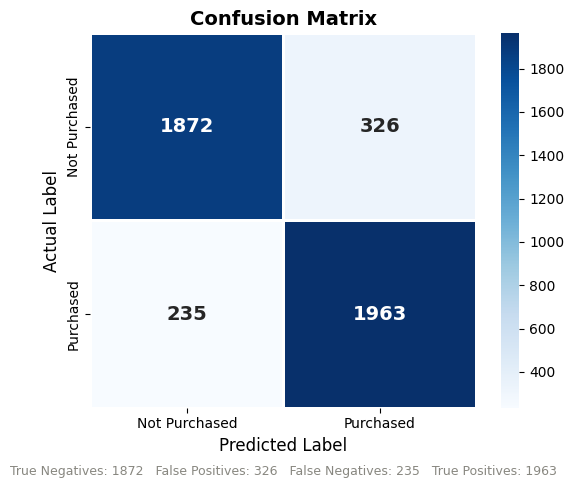

In [134]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Purchased", "Purchased"],
            yticklabels=["Not Purchased", "Purchased"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"}, ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("Actual Label",    fontsize=12)
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
 
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.18,
    f"True Negatives: {tn}   False Positives: {fp}   "
    f"False Negatives: {fn}   True Positives: {tp}",
    ha="center", transform=ax.transAxes,
    fontsize=9, color=GRAY)
 
plt.tight_layout()
plt.savefig("eval_chart1_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

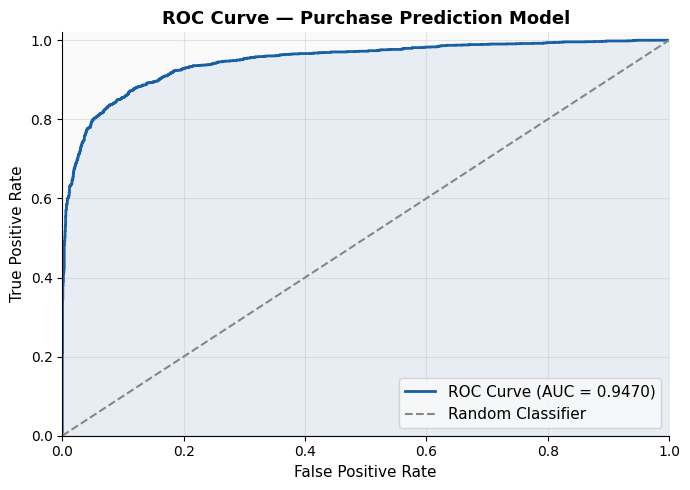

In [139]:
# CHART 2: ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
 
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color=BLUE, lw=2,
        label=f"ROC Curve (AUC = {roc_auc:.4f})")
ax.plot([0,1],[0,1], color=GRAY, lw=1.5,
        linestyle="--", label="Random Classifier")
ax.fill_between(fpr, tpr, alpha=0.08, color=BLUE)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Purchase Prediction Model")
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eval_chart2_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

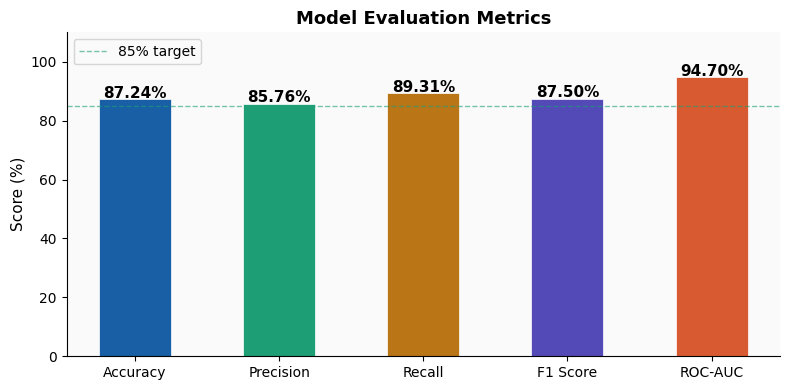

In [140]:
# METRICS COMPARISON BAR
metrics = {
    "Accuracy":  acc  * 100,
    "Precision": prec * 100,
    "Recall":    rec  * 100,
    "F1 Score":  f1   * 100,
    "ROC-AUC":   auc_s* 100,
}
fig, ax = plt.subplots(figsize=(8, 4))
colors  = [BLUE, TEAL, AMBER, PURPLE, CORAL]
bars    = ax.bar(metrics.keys(), metrics.values(),
                  color=colors, edgecolor="white", linewidth=0.5, width=0.5)
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.2f}%", ha="center",
            fontsize=11, fontweight="bold")
ax.set_ylim(0, 110)
ax.set_ylabel("Score (%)")
ax.set_title("Model Evaluation Metrics")
ax.axhline(y=85, color=TEAL, linestyle="--",
           linewidth=1, alpha=0.6, label="85% target")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("eval_chart3_metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()

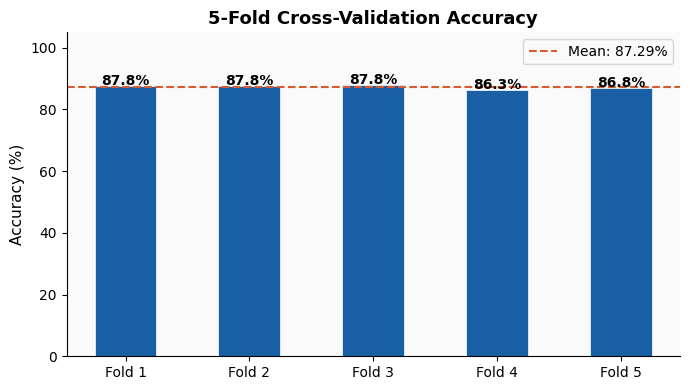

In [141]:
# CROSS-VALIDATION SCORES
fig, ax = plt.subplots(figsize=(7, 4))
folds   = [f"Fold {i+1}" for i in range(5)]
bars    = ax.bar(folds, cv_acc * 100,
                  color=BLUE, edgecolor="white",
                  linewidth=0.5, width=0.5)
for bar, val in zip(bars, cv_acc * 100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.axhline(y=cv_acc.mean()*100, color=CORAL, linestyle="--",
           linewidth=1.5, label=f"Mean: {cv_acc.mean()*100:.2f}%")
ax.set_ylim(0, 105)
ax.set_ylabel("Accuracy (%)")
ax.set_title("5-Fold Cross-Validation Accuracy")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("eval_chart4_cross_validation.png", dpi=150, bbox_inches="tight")
plt.show()

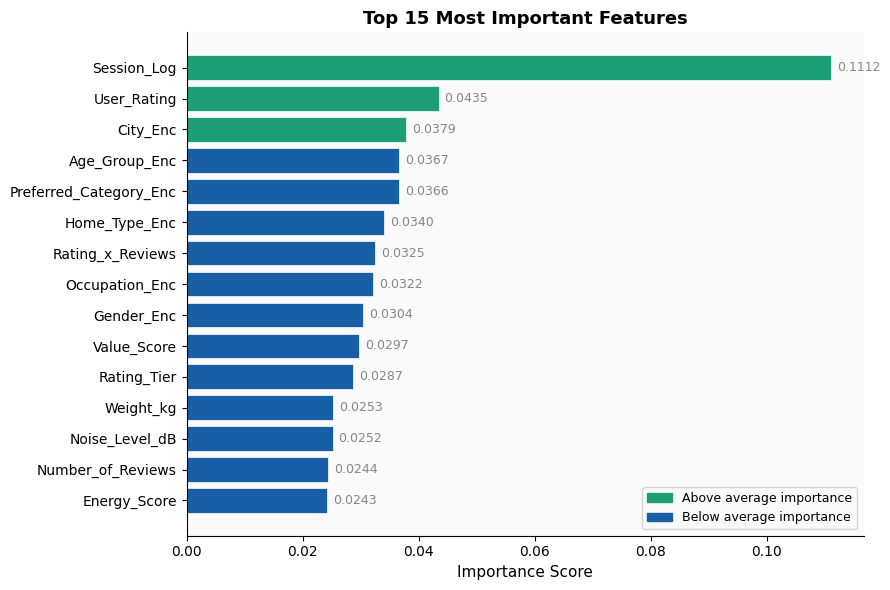

In [143]:
# FEATURE IMPORTANCE (TOP 15)
feat_imp = pd.Series(model.feature_importances_, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)
 
fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = [TEAL if v > feat_imp.mean() else BLUE for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values,
               color=colors_imp, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + 0.001,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9, color=GRAY)
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Most Important Features")
high_patch = mpatches.Patch(color=TEAL, label="Above average importance")
low_patch  = mpatches.Patch(color=BLUE, label="Below average importance")
ax.legend(handles=[high_patch, low_patch], fontsize=9)
plt.tight_layout()
plt.savefig("eval_chart5_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

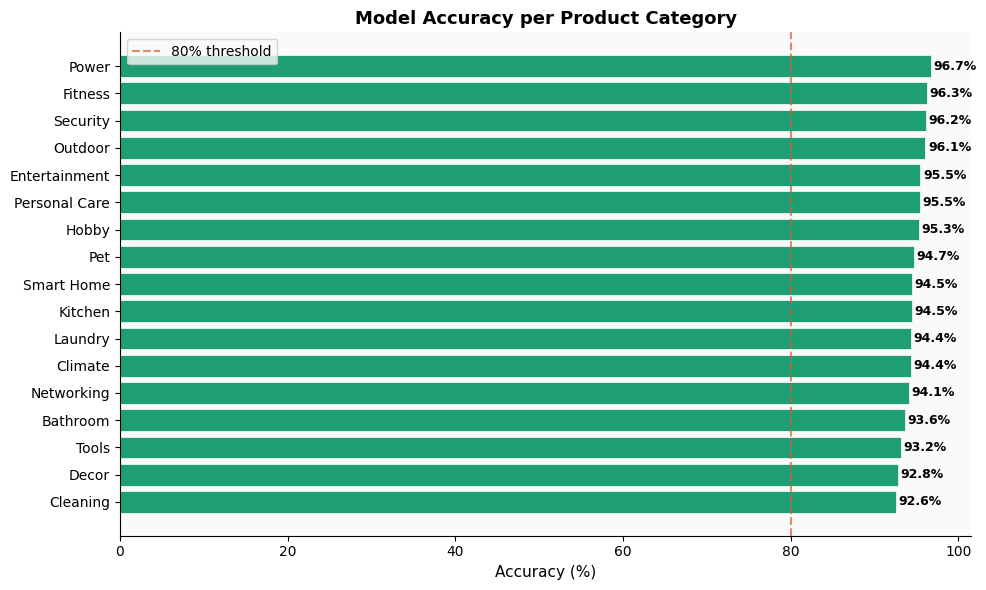

In [146]:
# PER-CATEGORY ACCURACY
categories = full["Category"].unique()
cat_results = []
 
for cat in sorted(categories):
    mask    = full["Category"] == cat
    X_cat   = full.loc[mask, FEATURES].fillna(0)
    y_cat   = full.loc[mask, "Purchased"]
    if len(X_cat) < 10: continue
    y_p     = model.predict(X_cat)
    cat_acc = accuracy_score(y_cat, y_p)
    cat_results.append({"Category": cat, "Accuracy": cat_acc * 100})
 
cat_df = pd.DataFrame(cat_results).sort_values("Accuracy", ascending=True)
 
fig, ax = plt.subplots(figsize=(10, 6))
colors_cat = [TEAL if v >= 80 else BLUE for v in cat_df["Accuracy"]]
bars = ax.barh(cat_df["Category"], cat_df["Accuracy"],
               color=colors_cat, edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, cat_df["Accuracy"]):
    ax.text(val + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax.axvline(x=80, color=CORAL, linestyle="--",
           linewidth=1.5, alpha=0.7, label="80% threshold")
ax.set_xlabel("Accuracy (%)")
ax.set_title("Model Accuracy per Product Category")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("eval_chart6_category_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

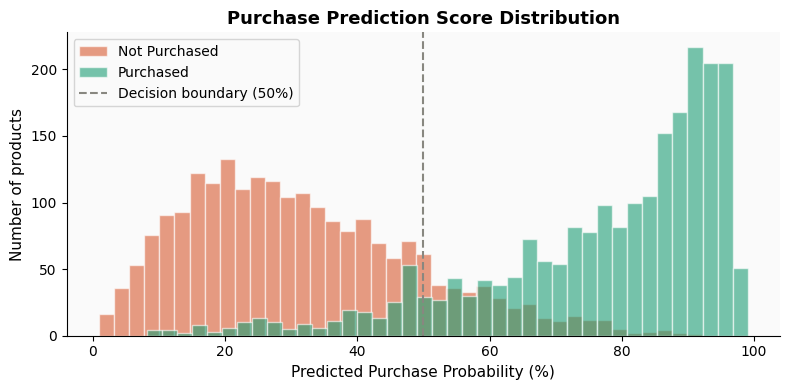

In [147]:
# PREDICTION SCORE DISTRIBUTION
y_prob_all = model.predict_proba(X_test)[:, 1]
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob_all[y_test==0]*100, bins=40,
        alpha=0.6, color=CORAL,  label="Not Purchased", edgecolor="white")
ax.hist(y_prob_all[y_test==1]*100, bins=40,
        alpha=0.6, color=TEAL,   label="Purchased",     edgecolor="white")
ax.axvline(x=50, color=GRAY, linestyle="--",
           linewidth=1.5, label="Decision boundary (50%)")
ax.set_xlabel("Predicted Purchase Probability (%)")
ax.set_ylabel("Number of products")
ax.set_title("Purchase Prediction Score Distribution")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("eval_chart7_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()